In [8]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [ ]:
from gaussian import Gaussian

from jax import vmap
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [10]:
mu = jnp.array([1.0, 2.0])
Sigma = jnp.array(
    [
        [1.0, 0.5],
        [0.5, 2.0],
    ]
)

G = Gaussian(mu=mu, Sigma=Sigma)
G

Gaussian(mu=Array([1., 2.], dtype=float32), Sigma=Array([[1. , 0.5],
       [0.5, 2. ]], dtype=float32))

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
from tueplots.constants.color import rgb

cmp_wd = LinearSegmentedColormap.from_list("wd", ["w", rgb.tue_dark], N=1024)

X, Y = jnp.mgrid[-2:4:200j, -2:4:200j]
nplot = X.shape[0]
XY = jnp.dstack((X, Y)).reshape(nplot**2, 2)
XY
Z = vmap(G.pdf)(XY).reshape(nplot, nplot)
Z

Array([[2.2410441e-04, 2.3390718e-04, 2.4401212e-04, ..., 4.5485303e-05,
        4.2856944e-05, 4.0359435e-05],
       [2.3996849e-04, 2.5053066e-04, 2.6142155e-04, ..., 5.1262236e-05,
        4.8312584e-05, 4.5508998e-05],
       [2.5668912e-04, 2.6805623e-04, 2.7978158e-04, ..., 5.7712739e-05,
        5.4406089e-05, 5.1262188e-05],
       ...,
       [3.0991816e-07, 3.4045709e-07, 3.7381056e-07, ..., 1.5009264e-03,
        1.4884390e-03, 1.4752884e-03],
       [2.7043663e-07, 2.9716159e-07, 3.2635819e-07, ..., 1.3784748e-03,
        1.3673600e-03, 1.3556320e-03],
       [2.3573868e-07, 2.5910245e-07, 2.8463350e-07, ..., 1.2646959e-03,
        1.2548253e-03, 1.2443860e-03]], dtype=float32)

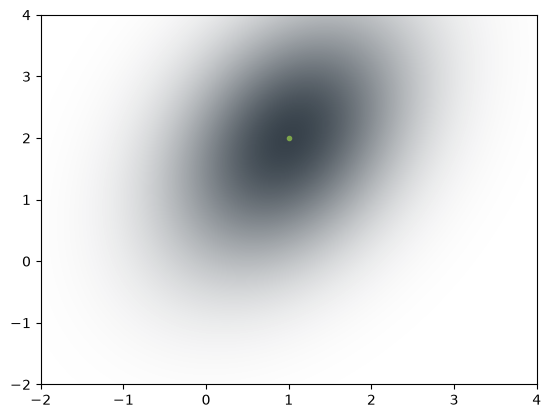

In [ ]:
fig, ax = plt.subplots()
ax.contourf(X, Y, Z, levels=200, cmap=cmp_wd)
ax.plot(mu[0], mu[1], "o", color=rgb.tue_green, markersize=3)

In [13]:
mu = jnp.array([1.0, 2.0, 3.0])
Sigma = jnp.array(
    [
        [1.0, 0.5, 0.0],
        [0.5, 2.0, 0.0],
        [0.0, 0.0, 3.0],
    ]
)
g1 = Gaussian(mu=mu, Sigma=Sigma)
g2 = Gaussian(mu=mu, Sigma=Sigma)

g3 = g1 * g2
g3

Gaussian(mu=Array([1.       , 2.0000002, 3.       ], dtype=float32), Sigma=Array([[0.5 , 0.25, 0.  ],
       [0.25, 1.  , 0.  ],
       [0.  , 0.  , 1.5 ]], dtype=float32))

In [14]:
g4 = g1 + 3
g4

Gaussian(mu=Array([4., 5., 6.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
       [0.5, 2. , 0. ],
       [0. , 0. , 3. ]], dtype=float32))